# Plant Disease Classification with Hybrid AI

This notebook implements a hybrid AI framework for classifying plant diseases from leaf images. 

**Architecture:**
1.  **Feature Extraction:** Uses a pre-trained **ResNet18** (or ResNet50) model as a feature extractor. The final classification layer is removed to obtain a rich 512-dimensional feature vector.
2.  **Classification:** These features are fed into a **Random Forest Classifier** (or Gradient Boosting Classifier) to predict the disease class.

**Key Optimizations:**
* **GPU Acceleration:** Feature extraction is performed on the GPU (if available).
* **Batch Processing:** Images are processed in batches (default: 512) to maximize throughput and minimize data transfer overhead.
* **Class Balancing:** The classifier uses balanced class weights to handle dataset imbalance.

In [14]:
import os
import time
from datetime import datetime
import cv2
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- CONFIGURATION ---
# In a notebook, __file__ is not defined, so we use the current working directory
script_dir = Path(os.getcwd())
dataset_path = script_dir.parent / 'dataset' 
log_file_path = script_dir / "experiment_log.txt"
print(f"Dataset path set to: {dataset_path}")
print(f"Log file path set to: {log_file_path}")
BATCH_SIZE = 256 # 256 works well for GPU feature extraction

# --- NOTEBOOK CONFIGURATION (Replaces argparse) ---
# Change these variables to switch modes
MODEL_TYPE = "RESNET18" # Options: "RESNET18", "RESNET50"
CLF_TYPE = "RF"       # Options: "RF" (Random Forest), "GB" (Gradient Boosting)
DATA_LIMIT = 256     # Set to an integer (e.g., 200) for testing, or None for all data

mode_name = f"Custom ({MODEL_TYPE} + {CLF_TYPE})"

Dataset path set to: d:\University\Final Year CSE\Semester1\Elective 3 Image Processing\Project\PlantVillage\dataset
Log file path set to: d:\University\Final Year CSE\Semester1\Elective 3 Image Processing\Project\PlantVillage\src\experiment_log.txt


## 1. Setup AI Feature Extractor

In [15]:
# Check for GPU availability
print("🔍 Checking for GPU availability...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")
if device.type == 'cuda':
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")

print(f"🧠 Loading {MODEL_TYPE}...")
if MODEL_TYPE == 'RESNET50':
    weights = models.ResNet50_Weights.DEFAULT
    resnet = models.resnet50(weights=weights)
else:
    weights = models.ResNet18_Weights.DEFAULT
    resnet = models.resnet18(weights=weights)

resnet = torch.nn.Sequential(
    *(list(resnet.children())[:-1]))  # Remove last layer

# MOVE MODEL TO GPU
resnet = resnet.to(device)
resnet.eval()

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

🔍 Checking for GPU availability...
🚀 Using Device: cuda
   GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
🧠 Loading RESNET18...


## 2. Helper Functions

In [16]:
def process_batch(images):
    """
    Takes a list of preprocessed tensors, stacks them into a batch,
    moves them to the GPU, and runs inference.
    """
    input_batch = torch.stack(images).to(device)
    with torch.no_grad():
        output = resnet(input_batch)
    # Flatten the output and move back to CPU as numpy array
    return output.view(input_batch.size(0), -1).cpu().numpy()

def load_data_with_ai(base_path, limit=200):
    features_list = []
    labels_list = []
    
    if not os.path.exists(base_path):
        print(f"❌ Error: Dataset path not found: {base_path}")
        return np.array([]), np.array([])

    class_names = os.listdir(base_path)
    
    print(f"⏳ Processing images with {MODEL_TYPE} features (Batch Size: {BATCH_SIZE})...")
    
    for class_name in class_names:
        if class_name == "PlantVillage":
            continue
        
        class_dir = os.path.join(base_path, class_name)
        if not os.path.isdir(class_dir):
            continue
        
        all_files = os.listdir(class_dir)
        # Apply limit if provided (None means all files)
        file_list = all_files[:limit] if limit else all_files
        
        print(f"   Extracting features for: {class_name} ({len(file_list)} images)")
        
        batch_images = []
        
        for img_name in file_list:
            img_path = os.path.join(class_dir, img_name)
            try:
                input_image = Image.open(img_path).convert('RGB')
                input_tensor = preprocess(input_image)
                batch_images.append(input_tensor)
                
                # If batch is full, process it
                if len(batch_images) >= BATCH_SIZE:
                    vectors = process_batch(batch_images)
                    features_list.extend(vectors)
                    labels_list.extend([class_name] * len(vectors))
                    batch_images = []
                    
            except Exception as e:
                print(f"Error reading {img_name}: {e}")
        
        # Process remaining images in the last batch
        if batch_images:
            vectors = process_batch(batch_images)
            features_list.extend(vectors)
            labels_list.extend([class_name] * len(vectors))
                
    return np.array(features_list), np.array(labels_list)

## 3. Main Execution Pipeline


⏱  Starting Performance Tracking on NVIDIA GeForce RTX 4060 Laptop GPU...
⚙  Mode: Custom (RESNET18 + RF)
⏳ Processing images with RESNET18 features (Batch Size: 256)...
   Extracting features for: Pepper__bell___Bacterial_spot (256 images)
   Extracting features for: Pepper__bell___healthy (256 images)
   Extracting features for: Potato___Early_blight (256 images)
   Extracting features for: Potato___healthy (152 images)
   Extracting features for: Potato___Late_blight (256 images)
   Extracting features for: Tomato_Bacterial_spot (256 images)
   Extracting features for: Tomato_Early_blight (256 images)
   Extracting features for: Tomato_healthy (256 images)
   Extracting features for: Tomato_Late_blight (256 images)
   Extracting features for: Tomato_Leaf_Mold (256 images)
   Extracting features for: Tomato_Septoria_leaf_spot (256 images)
   Extracting features for: Tomato_Spider_mites_Two_spotted_spider_mite (256 images)
   Extracting features for: Tomato__Target_Spot (256 images)


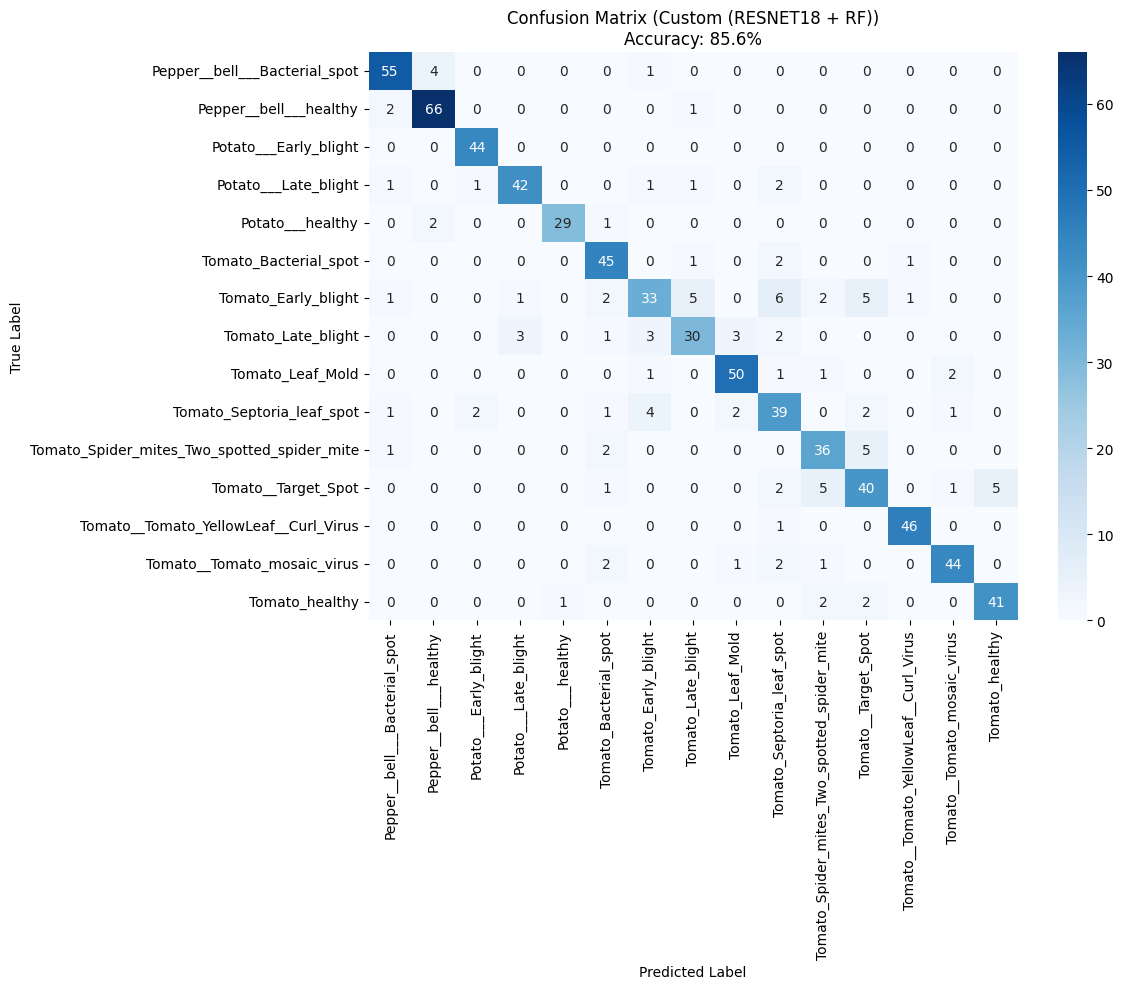

In [17]:
# Setup Logging
timings = {}

# Get Device Name for Log
device_name = "CPU"
if device.type == 'cuda':
    device_name = torch.cuda.get_device_name(0)

print(f"\n⏱  Starting Performance Tracking on {device_name}...")
print(f"⚙  Mode: {mode_name}")

# 1. Extract Features (NOW ON GPU)
start_time = time.time()

X, y = load_data_with_ai(dataset_path, limit=DATA_LIMIT)

timings[f"Feature Extraction ({MODEL_TYPE})"] = time.time() - start_time

if len(X) == 0:
    print("❌ No data loaded. Please check the dataset path.")
else:
    print(f"✅ Data Processed. Shape: {X.shape}")
    print(f"⏱  Feature Extraction took: {timings[f'Feature Extraction ({MODEL_TYPE})']:.2f}s")

    # 2. Split Data
    start_time = time.time()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
    timings["Data Splitting"] = time.time() - start_time

    # 3. Train Classifier
    start_time = time.time()

    if CLF_TYPE == 'GB':
        print("🚀 Training Gradient Boosting Model...")
        model = HistGradientBoostingClassifier(
            max_iter=1000,
            learning_rate=0.1,
            class_weight='balanced',
            random_state=42
        )
    else:
        print("🌲 Training Optimized Random Forest...")
        model = RandomForestClassifier(
            n_estimators=500,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )

    model.fit(X_train, y_train)
    timings[f"Classifier Training ({CLF_TYPE})"] = time.time() - start_time
    print(f"⏱  Training took: {timings[f'Classifier Training ({CLF_TYPE})']:.2f}s")

    # 4. Evaluation
    print("📊 Evaluating...")
    start_time = time.time()
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    timings["Evaluation"] = time.time() - start_time

    print(f"✨ Accuracy: {acc * 100:.2f}%")
    report_str = classification_report(y_test, y_pred)
    print("\nClassification Report:")
    print(report_str)

    # --- LOGGING TO FILE ---
    try:
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        with open(log_file_path, "a", encoding="utf-8") as f:
            f.write("=" * 80 + "\n")
            f.write(f"Timestamp: {timestamp}\n")
            f.write(f"Configuration: {mode_name}\n")
            f.write(f"Dataset Limit: {'ALL' if DATA_LIMIT is None else DATA_LIMIT}\n")
            f.write(f"Device: {device_name}\n")
            f.write(f"Overall Accuracy: {acc * 100:.2f}%\n")
            f.write("-" * 80 + "\n")
            f.write(f"Batch Size: {BATCH_SIZE}\n")
            f.write("Timing Breakdown:\n")
            for task, duration in timings.items():
                f.write(f"  - {task:<35}: {duration:.4f}s\n")
            f.write("-" * 80 + "\n")
            f.write("Detailed Classification Report:\n")
            f.write(report_str)
            f.write("\n" + "=" * 80 + "\n\n")

        print(f"\n📝 Experiment log updated: {log_file_path}")
    except Exception as e:
        print(f"⚠ Failed to write log: {e}")

    # 5. Visualization
    print("🎨 Plotting Confusion Matrix...")
    unique_classes = sorted(list(set(y)))
    cm = confusion_matrix(y_test, y_pred, labels=unique_classes)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_classes, yticklabels=unique_classes)
    plt.title(f'Confusion Matrix ({mode_name})\nAccuracy: {acc*100:.1f}%')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()